# Sex comparison: does the dose-rate decay rate differ by sex?

Requires `patient_data_clean.csv` and `lmm.py` in the same folder.

Extends the same mixed-effects model used for the main analysis:
log(dose rate) ~ time, random intercept per patient. Sex is tested
as a fixed-effect covariate on the intercept (starting dose rate)
and on the slope (decay rate), the same way weight/BMI/injected
activity were tested.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lmm import fit_lmm, lrt

df = pd.read_csv("./data/patient_data_clean.csv")
df["logDR"] = np.log(df["dose rate"])
df["male"] = (df["sex"] == "Male").astype(float)  # Female = reference (0)
patients = sorted(df["Patient"].unique())
T_PHYS = 109.771

def half_life(lam):
    return np.log(2) / lam

def build_lists(patient_ids, dataframe, extra_slope_cols=None, extra_int_cols=None, q=1):
    y_list, X_list, Z_list = [], [], []
    for pid in patient_ids:
        g = dataframe[dataframe["Patient"] == pid]
        t = g["time"].values.astype(float)
        cols = [np.ones_like(t), t]
        if extra_int_cols:
            for c in extra_int_cols:
                cols.append(g[c].values.astype(float))
        if extra_slope_cols:
            for c in extra_slope_cols:
                cols.append(g[c].values.astype(float) * t)
        X_i = np.column_stack(cols)
        y_list.append(g["logDR"].values)
        X_list.append(X_i)
        Z_list.append(X_i[:, :q])
    return y_list, X_list, Z_list

## 1. Check for imbalance between sexes before interpreting any effect

If sex is strongly correlated with weight, height, or injected
activity, a "sex effect" could really be one of those other
variables in disguise (as happened with weight vs. injected
activity in the main analysis) -- check this before interpreting
anything.

In [2]:
per_patient = df.groupby("Patient").first()
print("n patients by sex:")
print(per_patient["sex"].value_counts())
print()
print("Patient characteristics by sex (mean \u00b1 SD):")
print(per_patient.groupby("sex")[["weight", "height", "bmi", "injection dose"]].agg(["mean", "std"]).round(2))

n patients by sex:
sex
Male      21
Female    15
Name: count, dtype: int64

Patient characteristics by sex (mean ± SD):
       weight         height          bmi       injection dose      
         mean    std    mean   std   mean   std           mean   std
sex                                                                 
Female  76.53  14.35  162.40  9.39  28.97  4.99           8.24  1.45
Male    76.81  16.49  174.48  6.04  25.11  4.56           8.48  1.29


## 2. Mixed-effects model: sex on intercept, on slope, and on both

Fit by ML (reml=False) since we're comparing different fixed-effects
structures

REML LRT is not valid for that (same convention as
the covariate analysis in script 02).

In [3]:
y0, X0, Z0 = build_lists(patients, df)
fit0 = fit_lmm(y0, X0, Z0, reml=False, n_restarts=10, seed=2)

y_int, X_int, Z_int = build_lists(patients, df, extra_int_cols=["male"])
fit_int = fit_lmm(y_int, X_int, Z_int, reml=False, n_restarts=10, seed=3)
stat_int, p_int = lrt(fit0, fit_int, df=1)

y_slope, X_slope, Z_slope = build_lists(patients, df, extra_slope_cols=["male"])
fit_slope = fit_lmm(y_slope, X_slope, Z_slope, reml=False, n_restarts=10, seed=4)
stat_slope, p_slope = lrt(fit0, fit_slope, df=1)

y_both, X_both, Z_both = build_lists(patients, df, extra_int_cols=["male"], extra_slope_cols=["male"])
fit_both = fit_lmm(y_both, X_both, Z_both, reml=False, n_restarts=12, seed=5)
stat_both, p_both = lrt(fit0, fit_both, df=2)

print(f"Sex on intercept:            coef={fit_int['beta'][-1]:.5f}  se={fit_int['beta_se'][-1]:.5f}  LRT p={p_int:.4f}")
print(f"Sex on slope (decay rate):   coef={fit_slope['beta'][-1]:.6f}  se={fit_slope['beta_se'][-1]:.6f}  LRT p={p_slope:.4f}")
print(f"Sex on both (2 df):          LRT p={p_both:.4f}")

Sex on intercept:            coef=0.03477  se=0.04743  LRT p=0.4655
Sex on slope (decay rate):   coef=0.000212  se=0.000697  LRT p=0.7651
Sex on both (2 df):          LRT p=0.6463


## 3. Robustness check: does adjusting for injected activity change this?

Injected activity was the one covariate that held up in the main
analysis. If sex happened to be correlated with it, an apparent
sex effect could be riding on that association.
Check directly, the same way weight vs. injected activity was disentangled earlier.

In [4]:
df["dose_c"] = df["injection dose"] - df["injection dose"].mean()

y_d, X_d, Z_d = build_lists(patients, df, extra_slope_cols=["dose_c"])
fit_d = fit_lmm(y_d, X_d, Z_d, reml=False, n_restarts=10, seed=6)

y_sd, X_sd, Z_sd = build_lists(patients, df, extra_slope_cols=["male", "dose_c"])
fit_sd = fit_lmm(y_sd, X_sd, Z_sd, reml=False, n_restarts=12, seed=7)
stat_sd, p_sd = lrt(fit_d, fit_sd, df=1)

print(f"Sex on slope, adjusted for injected activity: coef={fit_sd['beta'][-2]:.6f}  LRT p={p_sd:.4f}")

Sex on slope, adjusted for injected activity: coef=0.000096  LRT p=0.8806


## 4. Descriptive per-sex Teff (from the fully-interacted model)

Reported for completeness even though the test above is not
significant
These are reported alongside the p-value, not instead
of it.

In [5]:
fit_both_reml = fit_lmm(y_both, X_both, Z_both, reml=True, n_restarts=15, seed=5)
beta0, beta_t, beta_male_int, beta_male_slope = fit_both_reml["beta"]

teff_female = half_life(-beta_t)
teff_male = half_life(-(beta_t + beta_male_slope))
print(f"Implied Teff, female (reference): {teff_female:.1f} min")
print(f"Implied Teff, male:               {teff_male:.1f} min")
print("(difference not statistically significant -- see Section 2 p-values)")

Implied Teff, female (reference): 92.8 min
Implied Teff, male:               84.1 min
(difference not statistically significant -- see Section 2 p-values)


## 5. Figure: raw dose rate over time, colored by sex

Saved figure_sex_comparison.png

Summary: no statistically significant difference in decay rate or
starting dose rate between sexes in this cohort (all p > 0.4, robust
to adjustment for injected activity).


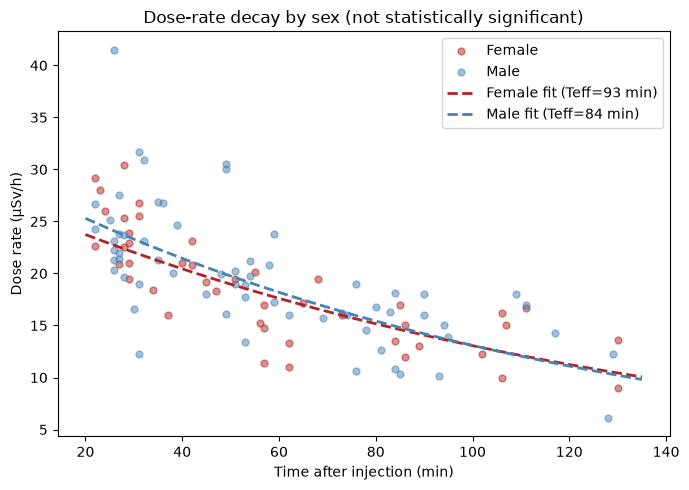

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = {"Female": "firebrick", "Male": "steelblue"}
for sx, color in colors.items():
    sub = df[df["sex"] == sx]
    ax.scatter(sub["time"], sub["dose rate"], alpha=0.5, s=25, color=color, label=sx)

t_grid = np.linspace(20, 135, 100)
ax.plot(t_grid, np.exp(beta0 + beta_t * t_grid), color=colors["Female"], lw=2, ls="--",
        label=f"Female fit (Teff={teff_female:.0f} min)")
ax.plot(t_grid, np.exp(beta0 + beta_male_int + (beta_t + beta_male_slope) * t_grid),
        color=colors["Male"], lw=2, ls="--", label=f"Male fit (Teff={teff_male:.0f} min)")
ax.set_xlabel("Time after injection (min)")
ax.set_ylabel("Dose rate (\u00b5Sv/h)")
ax.set_title("Dose-rate decay by sex (not statistically significant)")
ax.legend()
fig.tight_layout()
fig.savefig("figure_sex_comparison.png", dpi=150)
print("Saved figure_sex_comparison.png")

print("\nSummary: no statistically significant difference in decay rate or")
print("starting dose rate between sexes in this cohort (all p > 0.4, robust")
print("to adjustment for injected activity).")